In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.geometry import Point

import climattr as eea

plt.rcParams.update({'font.size': 14})

/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_64325/3112943099.py:1: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  cases = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])
/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_64325/3112943099.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  viridis = cm.get_cmap('Greys', n_colors)
/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_64325/3112943099.py:89: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cases_2024['centroid'] = cases_2024.geometry.centroid
/var/folders/d6/h_rjrby126j

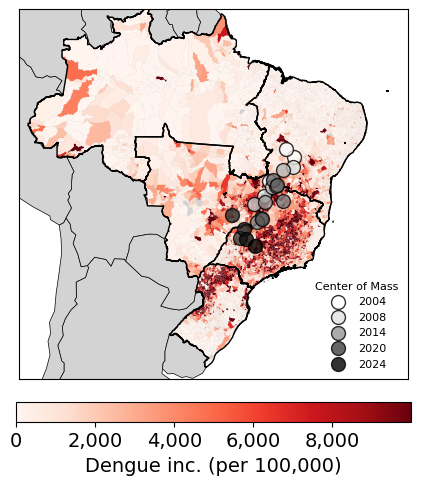

In [2]:
cases = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])

cases['month'] = cases['date_first_symptoms'].dt.month
cases['year'] = cases['date_first_symptoms'].apply(lambda x: x.year + 1 if x.month >= 8 else x.year)

cases_2024 = cases[cases['year'] == 2024].groupby(['region', 'city_residency']).agg({'n_cases': 'sum', 'population': 'mean'}).reset_index()
cases_2024['dengue_inc'] = cases_2024['n_cases'] / cases_2024['population'] * 100000
cases_2024['log_cases'] = np.log10(cases_2024['dengue_inc'] + 1)

gdf = gpd.read_file('utils/municipios/municipios.shp')
gdf['city_name'] = gdf['SIGLA_UF'] + '_' + gdf['city_name']

cases_2024 = eea.impacts.geolocate_dataframe(cases_2024, gdf, 'city_residency', 'city_name')

# Create figure and custom GridSpec layout (map on the left)
fig, ax_map = plt.subplots(figsize=(6, 6))

south_american_countries = [
    "Argentina",
    "Bolivia",
    "Brazil",
    "Chile",
    "Colombia",
    "Ecuador",
    "Guyana",
    "Paraguay",
    "Peru",
    "Suriname",
    "Uruguay",
    "Venezuela",
    "French Guiana", 
    "France"
]

world = gpd.read_file('utils/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')
south_america = world[world['SOVEREIGNT'].isin(south_american_countries)]

region = gpd.read_file('utils/BR_UF_2022/BR_UF_2022.shp')
region_agg = region.dissolve(by='NM_REGIAO')

# Brazil map on the left (spans both rows in column 0)
south_america.plot(ax=ax_map, color='lightgrey', edgecolor='black', lw=0.5)
plot = cases_2024.plot(
    ax=ax_map, 
    column='dengue_inc', 
    vmin=0,
    vmax=10000,
    cmap='Reds',
    legend=True,
    legend_kwds={"label": "Dengue inc. (per 100,000)", "orientation": "horizontal", "pad": 0.05, 'shrink': 0.85}
)
region_agg.plot(ax=ax_map, color='none', edgecolor='black', lw=1)
ax_map.set_xlim([-75, -30])
ax_map.set_ylim([-35, 5])
ax_map.set_xticks([])
ax_map.set_yticks([])

# Access colorbar axis (usually the last one)
cbar_ax = plot.figure.axes[-1]

# Set custom tick labels
new_labels = ['0', '2,000', '4,000', '6,000', '8,000']  # for example
cbar_ax.set_xticks([0, 2000, 4000, 6000, 8000])  # set the ticks you want
cbar_ax.set_xticklabels(new_labels)

##### Center of Mass
cases_year = cases.groupby(['region', 'city_residency', 'year']).sum(numeric_only=True).reset_index()
cases_year['log_cases'] = np.log10(cases_year['dengue_inc'] + 1)

gdf = gpd.read_file('utils/municipios/municipios.shp')
gdf['city_name'] = gdf['SIGLA_UF'] + '_' + gdf['city_name']

cases_year = eea.impacts.geolocate_dataframe(cases_year, gdf, 'city_residency', 'city_name')

years = np.arange(2004, 2025)
n_colors = len(years)

# Get the colormap
viridis = cm.get_cmap('Greys', n_colors)

# Generate list of colors as hex codes
viridis_colors_hex = [mcolors.to_hex(viridis(i)) for i in range(n_colors)]
sizes = np.linspace(5,100, n_colors)

for year, color, size in zip(years, viridis_colors_hex, sizes):
    cases_2024 = cases_year[cases_year['year'] == year].copy()

    # === Step 2: Calculate centroids
    cases_2024['centroid'] = cases_2024.geometry.centroid

    # === Step 3: Get x and y from centroids
    cases_2024['x'] = cases_2024['centroid'].x
    cases_2024['y'] = cases_2024['centroid'].y

    # === Step 4: Compute the weighted average (center of mass)
    total_cases = cases_2024['dengue_inc'].mean()
    x_com = (cases_2024['x'] * cases_2024['dengue_inc']).mean() / total_cases
    y_com = (cases_2024['y'] * cases_2024['dengue_inc']).mean() / total_cases

    # === Step 5: Create a GeoSeries for the center of mass
    com_point = gpd.GeoSeries([Point(x_com, y_com)], crs=cases_2024.crs)
    com_point.plot(ax=ax_map, color=color, marker='o', markersize=100, alpha=0.8, edgecolor='k')

# === Create dummy legend handles
legend_handles = [
    plt.scatter([], [], s=100, color='#ffffff', label='2004', alpha=0.8, edgecolor='k'),
    plt.scatter([], [], s=100, color='#e2e2e2', label='2008', alpha=0.8, edgecolor='k'),
    plt.scatter([], [], s=100, color='#969696', label='2014', alpha=0.8, edgecolor='k'),
    plt.scatter([], [], s=100, color='#404040', label='2020', alpha=0.8, edgecolor='k'),
    plt.scatter([], [], s=100, color='#000000', label='2024', alpha=0.8, edgecolor='k'),
]

# === Add legend
ax_map.legend(handles=legend_handles, loc='lower right', frameon=False, fontsize=8, title='Center of Mass', title_fontsize=8)

plt.savefig('img/figure1_map.pdf', bbox_inches='tight', dpi=300)

In [ ]:
df = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])
df['year'] = df['date_first_symptoms'].apply(lambda x: x.year + 1 if x.month >= 8 else x.year)

df = df.groupby(['city_residency', 'year']).agg({'n_cases': 'sum', 'population': 'mean'}).reset_index()
df['dengue_inc'] = 1e5 * df['n_cases'] / df['population']

df['rank'] = df.groupby(['city_residency'])['dengue_inc'].rank(method='dense', ascending=False)

# Filter data for years before 2023
df_before_2023 = df[df['year'] < 2023]

# Method 1: Direct approach - find cities with max incidence <= 300
cities_max_incidence = df_before_2023.groupby('city_residency')['dengue_inc'].max()
cities_no_high_incidence = cities_max_incidence[cities_max_incidence <= 300].index.tolist()

df = df[df['year'] == 2024]

gdf = gpd.read_file('utils/municipios/municipios.shp')
gdf['city_residency'] = gdf['SIGLA_UF'] + '_' + gdf['city_name']

region = gpd.read_file('utils/BR_UF_2022/BR_UF_2022.shp')
region_agg = region.dissolve(by='NM_REGIAO')

gdf = eea.impacts.geolocate_dataframe(df, gdf, 'city_residency', 'city_residency')
gdf['log_inc'] = np.log10(gdf['dengue_inc'])

south_american_countries = [
    "Argentina",
    "Bolivia",
    "Brazil",
    "Chile",
    "Colombia",
    "Ecuador",
    "Guyana",
    "Paraguay",
    "Peru",
    "Suriname",
    "Uruguay",
    "Venezuela",
    "French Guiana",
    "France"
]

world = gpd.read_file('utils/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')
south_america = world[world['SOVEREIGNT'].isin(south_american_countries)]

fig, ax = plt.subplots(figsize=(6,6))

south_america.plot(ax=ax, color='lightgrey', edgecolor='black', lw=0.5)
plot = gdf.plot(
    column='rank', 
    ax=ax, 
    cmap='Blues_r',
    legend=True,
    legend_kwds={"label": "Rank of 2024", "orientation": "horizontal", "pad": 0.05, 'shrink': 0.85},
)
gdf[gdf['city_residency'].isin(cities_no_high_incidence) & (gdf['dengue_inc'] > 300)].plot(
    ax=ax, 
    #edgecolor='k', 
    facecolor='C1',
)
region_agg.plot(ax=ax, facecolor='none', edgecolor='k')

ax.set_xlim([-75, -30])
ax.set_ylim([-35, 5])
ax.set_xticks([])
ax.set_yticks([])

# Access colorbar axis (usually the last one)
cbar_ax = plot.figure.axes[-1]

# Set custom tick labels
cbar_ax.set_xticks([1, 5, 10, 15, 20])  # set the ticks you want


# ---- LEGEND ----
legend_elements = [
    Patch(facecolor='C1', label='First year \nwith incidence\n> 300 per 100,000',),
]
fig.legend(handles=legend_elements, frameon=False, ncol=1, bbox_to_anchor=(0.86, 0.37), fontsize=10)
plt.savefig('img/figure1_ranking.pdf', dpi=300, bbox_inches='tight')


/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_64325/2312238312.py:1: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])
/opt/anaconda3/envs/impact-env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_60426/710392642.py:32: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  prior_immunity =  pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])


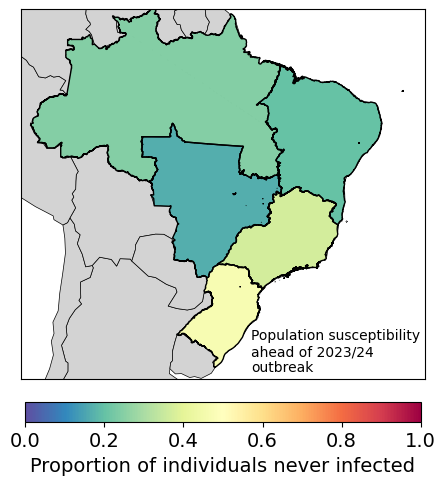

In [ ]:

gdf = gpd.read_file('../supplementary/shapefiles/municipios/municipios.shp')
gdf['city_name'] = gdf['SIGLA_UF'] + '_' + gdf['city_name']

# Create figure and custom GridSpec layout (map on the left)
fig, ax_map = plt.subplots(figsize=(6, 6))

south_american_countries = [
    "Argentina",
    "Bolivia",
    "Brazil",
    "Chile",
    "Colombia",
    "Ecuador",
    "Guyana",
    "Paraguay",
    "Peru",
    "Suriname",
    "Uruguay",
    "Venezuela",
    "French Guiana", 
    "France"
]

world = gpd.read_file('utils/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp')
south_america = world[world['SOVEREIGNT'].isin(south_american_countries)]

region = gpd.read_file('utils/BR_UF_2022/BR_UF_2022.shp')
region_agg = region.dissolve(by='NM_REGIAO')
region_agg['region'] = region_agg.index
region_agg['region'] = region_agg['region'].replace({'Centro-oeste\n': 'Centre-West', 'Nordeste\n': 'Northeast', 'Norte': 'North', 'Sudeste\n': 'Southeast', 'Sul\n': 'South'})

prior_immunity =  pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])
prior_immunity['region'] = prior_immunity['region'].replace({'Middle-West': 'Centre-West'})

prior_immunity = prior_immunity.groupby(['date_first_symptoms', 'region'])['Pr_0priorinf'].mean().reset_index()
prior_immunity = prior_immunity[prior_immunity['date_first_symptoms'] == pd.to_datetime('2024-01-01')]

prior_immunity = region_agg.set_index('region').join(prior_immunity.set_index('region'))

# Brazil map on the left (spans both rows in column 0)
south_america.plot(ax=ax_map, color='lightgrey', edgecolor='black', lw=0.5)
plot = prior_immunity.plot(
    ax=ax_map, 
    column='Pr_0priorinf', 
    vmin=0,
    vmax=1,
    cmap='Spectral_r',
    legend=True,
    legend_kwds={"label": "Proportion of individuals never infected", "orientation": "horizontal", "pad": 0.05, 'shrink': 0.85}
)
region_agg.plot(ax=ax_map, color='none', edgecolor='black', lw=1)
ax_map.set_xlim([-75, -30])
ax_map.set_ylim([-35, 5])
ax_map.set_xticks([])
ax_map.set_yticks([])

ax_map.text(
    0.57, 0.02, 'Population susceptibility\nprior to 2023/24\noutbreak', transform=ax_map.transAxes, fontsize=10
)

# Access colorbar axis (usually the last one)
cbar_ax = plot.figure.axes[-1]

plt.savefig('img/figure1_immunity.pdf', bbox_inches='tight', dpi=300)

/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_60426/4016550891.py:2: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  era5 = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])
/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_60426/4016550891.py:13: FutureWarning: The provided callable <function sum at 0x1055d1090> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  era5_temp = era5_temp.groupby(['region', 'year', 'month']).agg({
/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_60426/4016550891.py:13: FutureWarning: The provided callable <function sum at 0x1055d1090> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" in

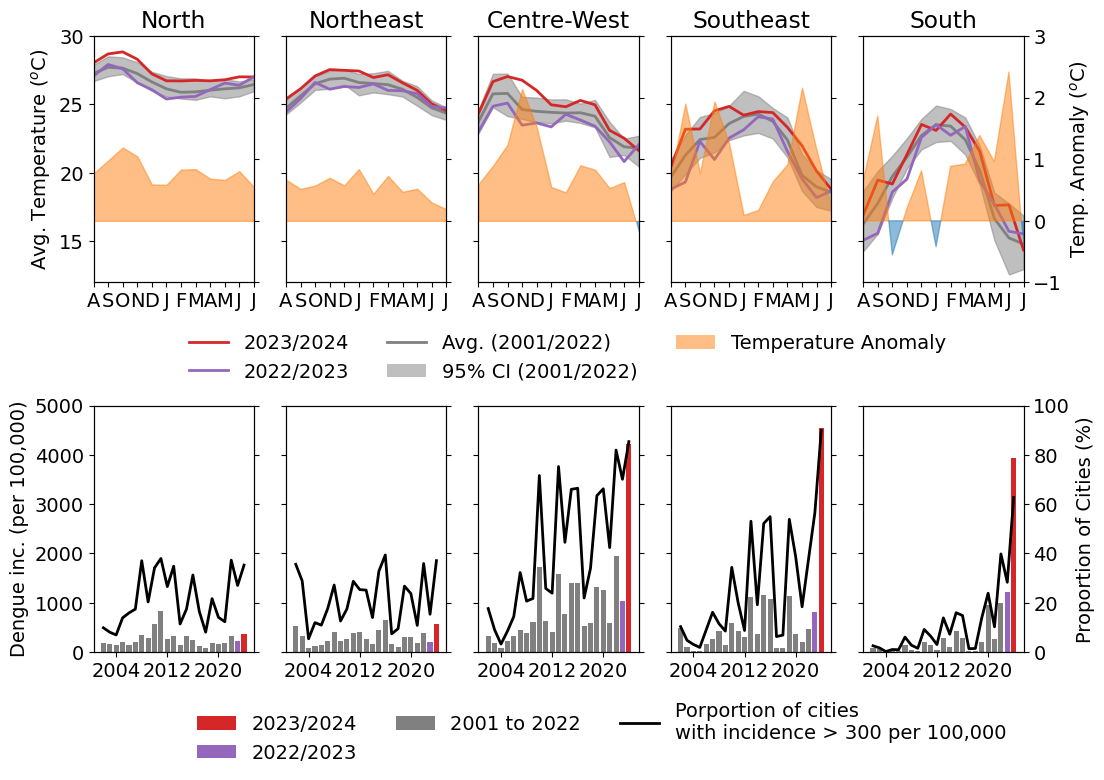

In [5]:
# Load and preprocess data once
era5 = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv', parse_dates=['date_first_symptoms'])
era5['month'] = era5['date_first_symptoms'].dt.month
era5['year'] = era5['date_first_symptoms'].apply(lambda x: x.year + 1 if x.month >= 8 else x.year)

# Prepare geospatial data for 2024
gdf = gpd.read_file('utils/municipios/municipios.shp')
gdf['city_name'] = gdf['SIGLA_UF'] + '_' + gdf['city_name']

# Prepare temperature data
era5_temp = era5.copy()
era5_temp['weighted_temp'] = era5_temp['mean_2m_air_temp_degree1'] * era5_temp['population']
era5_temp = era5_temp.groupby(['region', 'year', 'month']).agg({
    'weighted_temp': np.sum, 
    'n_cases': np.sum, 
    'population': np.sum
}).reset_index()
era5_temp['weighted_temp'] = era5_temp['weighted_temp'] / era5_temp['population']

# Prepare dengue incidence data
cases_city = era5.groupby(['region', 'year', 'city_residency']).agg({
    'n_cases': np.sum, 
    'population': np.mean
}).reset_index()
cases_city['dengue_inc'] = cases_city['n_cases'] / cases_city['population'] * 100000
cases_city['epidemic_year'] = 0
cases_city.loc[cases_city['dengue_inc'] >= 300, 'epidemic_year'] = 1

# Regional dengue incidence
cases_regional = era5.groupby(['region', 'city_residency', 'year']).agg({
    'n_cases': np.sum, 
    'population': np.mean
}).reset_index()
cases_regional = cases_regional.groupby(['region', 'year']).agg({
    'n_cases': np.sum, 
    'population': np.sum
}).reset_index()
cases_regional['dengue_inc'] = cases_regional['n_cases'] / cases_regional['population'] * 100000

# Epidemic proportions
epidemic_years = cases_city.groupby(['year', 'region']).mean(numeric_only=True).reset_index()

# Create figure
fig, axarr = plt.subplots(2, 5, figsize=(12, 8))
plt.subplots_adjust(wspace=0.2, hspace=0.5)

regions = ['North', 'Northeast', 'Middle-West', 'Southeast', 'South']

# ---- FIRST ROW: Temperature plots ----
for i, (nm_regiao, ax) in enumerate(zip(regions, axarr[0].flatten())):    
    era5_subset = era5_temp[era5_temp['region'] == nm_regiao][['month', 'year', 'weighted_temp']]
    era5_subset['x'] = era5_subset['month'].apply(lambda x: x - 8 if x >= 8 else x + 4)
    era5_subset = era5_subset.sort_values('x')
    era5_pivot = era5_subset.pivot_table(index='x', columns='year', values='weighted_temp')
    
    era5_pivot.iloc[:, :-2].mean(axis=1).plot(ax=ax, legend=False, color='grey', lw=2)
    era5_pivot.iloc[:, -1].plot(ax=ax, legend=False, color='C3', lw=2)
    era5_pivot.iloc[:, -2].plot(ax=ax, legend=False, color='C4', lw=2)
    
    ax.fill_between(
        era5_pivot.index, 
        era5_pivot.iloc[:, :-2].quantile(0.025, axis=1), 
        era5_pivot.iloc[:, :-2].quantile(0.975, axis=1),
        color='grey', alpha=0.5
    )
    
    axt = ax.twinx()
    diff = era5_pivot.iloc[:, -1] - era5_pivot.iloc[:, :-2].mean(axis=1)

    diff_neg = diff.copy()
    diff_neg[diff_neg > 0] = 0

    axt.fill_between(diff.index, 0, diff, where=diff >= 0, color='C1', alpha=0.5, interpolate=True)
    axt.fill_between(diff_neg.index, 0, diff, where=diff < 0, color='C0', alpha=0.5, interpolate=True)

    ax.set_xticks(np.arange(12))
    ax.set_xticklabels(['A', 'S', 'O', 'N', 'D', 'J', 'F', 'M', 'A', 'M', 'J', 'J'])
    ax.set_title(nm_regiao) if nm_regiao != 'Middle-West' else ax.set_title('Centre-West')
    ax.set_xlim(0, 11)
    ax.set_xlabel('')
    ax.set_ylim([12, 30])

    axt.set_ylim([-1, 3])
    if i < 4:
        axt.set_yticklabels([])

    if i != 0:
        ax.set_yticklabels([])

axarr[0, 0].set_ylabel(r'Avg. Temperature ($^o$C)')
axt.set_ylabel('Temp. Anomaly ($^o$C)')

# ---- LEGEND ----
legend_elements = [
    Line2D([0], [0], color='C3', lw=2, label='2023/2024'),
    Line2D([0], [0], color='C4', lw=2, label='2022/2023'),
    Line2D([0], [0], color='grey', lw=2, label='Avg. (2001/2022)'),
    Patch(facecolor='grey', alpha=0.5, label='95% CI (2001/2022)'),
    Patch(facecolor='C1', alpha=0.5, label='Temperature Anomaly'),
]
fig.legend(handles=legend_elements, frameon=False, ncol=3, bbox_to_anchor=(0.85, 0.53))

# ---- SECOND ROW: Dengue incidence plots ----
for i, (nm_regiao, ax) in enumerate(zip(regions, axarr[1].flatten())):    
    era5_subset = cases_regional[cases_regional['region'] == nm_regiao][['year', 'dengue_inc']]
    era5_subset = era5_subset.sort_values('year')

    ax.bar(era5_subset['year'], era5_subset['dengue_inc'], color='grey')
    ax.bar(era5_subset.iloc[[-1]]['year'], era5_subset.iloc[[-1]]['dengue_inc'], color='C3')
    ax.bar(era5_subset.iloc[[-2]]['year'], era5_subset.iloc[[-2]]['dengue_inc'], color='C4')
        
    ax.set_xticks([2004, 2012, 2020])
    ax.set_ylim([0, 5000])

    if i != 0:
        ax.set_yticklabels([])

    axt = ax.twinx()

    subset = epidemic_years[epidemic_years['region'] == nm_regiao]

    axt.plot(subset['year'], subset['epidemic_year'] * 100, color='k', lw=2)
    axt.set_ylim([0, 100])

    if i < 4:
        axt.set_yticklabels([])

axarr[1, 0].set_ylabel(r'Dengue inc. (per 100,000)')
axarr[1, -1].set_yticklabels([])
axt.set_ylabel('Proportion of Cities (%)')

# ---- LEGEND ----
legend_elements = [
    Patch(facecolor='C3', label='2023/2024'),
    Patch(facecolor='C4', label='2022/2023'),
    Patch(facecolor='grey', label='2001 to 2022'),
    Line2D([0], [0], color='k', lw=2, label='Porportion of cities\nwith incidence > 300 per 100,000'),
]
fig.legend(handles=legend_elements, frameon=False, ncol=3, bbox_to_anchor=(0.9, 0.07))


plt.savefig('img/figure1_temp_timeseries.pdf', bbox_inches='tight', dpi=300)